In [1]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
file_path = r'C:\Users\sharif\Desktop\6.9-Final_AllReactive.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""ETHANOL"").T","STREAMS(""P-ACID"").T","STREAMS(""S15"").T","STREAMS(""C1-INPUT"").T","STREAMS(""S26"").T","STREAMS(""S28"").T","STREAMS(""ETHANOL"").P","STREAMS(""P-ACID"").P","STREAMS(""S15"").P","STREAMS(""C1-INPUT"").P",...,"BLOCKS(""C1"").Stage(29).T","BLOCKS(""C1"").Stage(30).T","BLOCKS(""C1"").Stage(31).T","BLOCKS(""C1"").Stage(32).T","BLOCKS(""C1"").Stage(33).T","STREAMS(""D1"").Zmn(""ETHYL-01"")","STREAMS(""S29"").Zmn(""ETHYL-01"")","STREAMS(""S8"").Zmn(""ETHYL-01"")","STREAMS(""S29"").F","STREAMS(""D1"").F"
0,25.0,25.0,146.692,139.972,25.4830,25.3346,1.01325,1.01325,1.20551,1.20551,...,141.881,142.038,142.194,142.349,142.584,0.933737,0.999927,0.740045,49.0159,287.386
1,25.0,25.0,146.693,139.972,25.4839,25.3356,1.01325,1.01325,1.20552,1.20552,...,141.883,142.039,142.195,142.351,142.585,0.933735,0.999927,0.740045,49.0159,287.387
2,25.0,25.0,146.693,139.972,25.4844,25.3361,1.01325,1.01325,1.20552,1.20552,...,141.884,142.040,142.196,142.352,142.586,0.933733,0.999927,0.740045,49.0159,287.387
3,25.0,25.0,146.693,139.972,25.4846,25.3363,1.01325,1.01325,1.20552,1.20552,...,141.884,142.041,142.197,142.352,142.586,0.933731,0.999927,0.740045,49.0160,287.387
4,25.0,25.0,146.693,139.972,25.4848,25.3365,1.01325,1.01325,1.20553,1.20553,...,141.885,142.041,142.197,142.352,142.586,0.933730,0.999927,0.740045,49.0160,287.387


In [3]:
df.describe

<bound method NDFrame.describe of        STREAMS("ETHANOL").T  STREAMS("P-ACID").T  STREAMS("S15").T  \
0                      25.0                 25.0           146.692   
1                      25.0                 25.0           146.693   
2                      25.0                 25.0           146.693   
3                      25.0                 25.0           146.693   
4                      25.0                 25.0           146.693   
...                     ...                  ...               ...   
11181                  25.0                 25.0           146.736   
11182                  25.0                 25.0           146.736   
11183                  25.0                 25.0           146.736   
11184                  25.0                 25.0           146.736   
11185                  25.0                 25.0           146.736   

       STREAMS("C1-INPUT").T  STREAMS("S26").T  STREAMS("S28").T  \
0                    139.972           25.4830           

In [4]:
x = df.iloc[:, :-5].values
y = df.iloc[:, -5:].values 

In [5]:
x

array([[ 25.   ,  25.   , 146.692, ..., 142.194, 142.349, 142.584],
       [ 25.   ,  25.   , 146.693, ..., 142.195, 142.351, 142.585],
       [ 25.   ,  25.   , 146.693, ..., 142.196, 142.352, 142.586],
       ...,
       [ 25.   ,  25.   , 146.736, ..., 142.237, 142.392, 142.625],
       [ 25.   ,  25.   , 146.736, ..., 142.237, 142.392, 142.625],
       [ 25.   ,  25.   , 146.736, ..., 142.237, 142.392, 142.625]],
      shape=(11186, 83))

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)

In [8]:
# خروجی‌ها رو هم جدا می‌کنیم به دو بخش
y_train_conc = y_train[:, :3]  # غلظت‌ها
y_train_flow = y_train[:, 3:]  # دبی‌ها

y_test_conc = y_test[:, :3]
y_test_flow = y_test[:, 3:]

In [9]:
y_train_conc

array([[0.934845, 0.999927, 0.739736],
       [0.932403, 0.999927, 0.738654],
       [0.932633, 0.999927, 0.739174],
       ...,
       [0.931811, 0.999927, 0.740268],
       [0.933677, 0.999927, 0.739998],
       [0.932064, 0.999927, 0.73957 ]], shape=(8948, 3))

In [10]:
y_train_flow

array([[ 49.4711, 289.06  ],
       [ 49.0542, 289.31  ],
       [ 48.9858, 288.056 ],
       ...,
       [ 48.3997, 284.272 ],
       [ 48.9999, 287.316 ],
       [ 48.6283, 286.408 ]], shape=(8948, 2))

In [11]:
y_scaler_conc = MinMaxScaler()
y_scaler_flow = MinMaxScaler()

y_train_conc_scaled = y_scaler_conc.fit_transform(y_train_conc)
y_test_conc_scaled = y_scaler_conc.transform(y_test_conc)

y_train_flow_scaled = y_scaler_flow.fit_transform(y_train_flow)
y_test_flow_scaled = y_scaler_flow.transform(y_test_flow)

In [12]:
y_train_conc_scaled

array([[0.83145275, 1.        , 0.45807093],
       [0.2574048 , 1.        , 0.09943653],
       [0.31147156, 1.        , 0.27179317],
       ...,
       [0.11824165, 1.        , 0.63440504],
       [0.55688764, 1.        , 0.54491216],
       [0.17771509, 1.        , 0.40304939]], shape=(8948, 3))

In [13]:
y_train_flow_scaled

array([[0.95415994, 0.92089907],
       [0.67353258, 0.94791442],
       [0.62749058, 0.81240545],
       ...,
       [0.23296984, 0.40350119],
       [0.63698169, 0.73244003],
       [0.38684707, 0.63432029]], shape=(8948, 2))

In [14]:
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
import numpy as np

# دیتاست با توجه به seq_len و جداکردن توابع __getitem__ و __len__
class MyDataset(Dataset):
    def __init__(self, X, y_conc, y_flow, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_conc = torch.tensor(y_conc, dtype=torch.float32)
        self.y_flow = torch.tensor(y_flow, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return self.X.shape[0] - self.seq_len + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.seq_len, :]
        y_conc_seq = self.y_conc[idx + self.seq_len - 1, :]
        y_flow_seq = self.y_flow[idx + self.seq_len - 1, :]
        return x_seq, y_conc_seq, y_flow_seq


In [15]:
# مدل LSTM با دو شاخه خروجی (بدون تغییر ساختار اصلی)
class VALSTM_MultiOutput(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim_conc, output_dim_flow):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(input_dim, hidden_dim * 4))
        self.U = nn.Parameter(torch.Tensor(hidden_dim, hidden_dim * 4))
        self.bias = nn.Parameter(torch.Tensor(hidden_dim * 4))

        self.Wa = nn.Parameter(torch.Tensor(input_dim, input_dim))
        self.Ua = nn.Parameter(torch.Tensor(hidden_dim * 2, input_dim))
        self.ba = nn.Parameter(torch.Tensor(input_dim))
        self.Va = nn.Parameter(torch.Tensor(input_dim, input_dim))
        self.softmax = nn.Softmax(dim=1)

        # دو لایه خروجی مجزا
        self.fc_conc = nn.Linear(hidden_dim, output_dim_conc)
        self.fc_flow = nn.Linear(hidden_dim, output_dim_flow)

        self.hidden_dim = hidden_dim
        self.init_weights()

    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_dim)
        for w in self.parameters():
            w.data.uniform_(-stdv, stdv)

    def forward(self, x):
        batch, seq_len, _ = x.size()
        h_t = torch.zeros(batch, self.hidden_dim).to(x.device)
        c_t = torch.zeros(batch, self.hidden_dim).to(x.device)
        hidden_seq = []
        for t in range(seq_len):
            x_t = x[:, t, :]
            attn = torch.tanh(x_t @ self.Wa + torch.cat([h_t, c_t], dim=1) @ self.Ua + self.ba) @ self.Va
            alpha = self.softmax(attn)
            x_t = alpha * x_t
            gates = x_t @ self.W + h_t @ self.U + self.bias
            i, f, g, o = torch.sigmoid(gates[:, :self.hidden_dim]), torch.sigmoid(gates[:, self.hidden_dim:2*self.hidden_dim]), torch.tanh(gates[:, 2*self.hidden_dim:3*self.hidden_dim]), torch.sigmoid(gates[:, 3*self.hidden_dim:])
            c_t = f * c_t + i * g
            h_t = o * torch.tanh(c_t)
            hidden_seq.append(h_t.unsqueeze(0))
        hidden_seq = torch.cat(hidden_seq, dim=0).transpose(0,1)
        final = hidden_seq[:, -1, :]

        out_conc = self.fc_conc(final)
        out_flow = self.fc_flow(final)

        return out_conc, out_flow, alpha


In [16]:
# تنظیمات اولیه
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seq_len = 20
batch_size = 64
epochs = 150

In [17]:
input_dim = x_train_scaled.shape[1]
hidden_dim = 64
output_dim_conc = 3
output_dim_flow = 2

In [18]:
# دیتاست و دیتالودر
train_ds = MyDataset(x_train_scaled, y_train_conc_scaled, y_train_flow_scaled, seq_len)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)


In [19]:
# مدل
model = VALSTM_MultiOutput(input_dim=input_dim, hidden_dim=hidden_dim,
                           output_dim_conc=output_dim_conc, output_dim_flow=output_dim_flow).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


In [34]:
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb_conc, yb_flow in train_loader:
        xb, yb_conc, yb_flow = xb.to(device), yb_conc.to(device), yb_flow.to(device)
        pred_conc, pred_flow, _ = model(xb)

        loss_conc = criterion(pred_conc, yb_conc)
        loss_flow = criterion(pred_flow, yb_flow)
        loss =20* loss_conc + 100 * loss_flow

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # داده‌های تست رو به صورت دنباله‌ای آماده می‌کنیم
    x_test_seq = []
    for i in range(len(x_test_scaled) - seq_len + 1):
        x_test_seq.append(x_test_scaled[i:i+seq_len, :])

    x_test_seq = torch.tensor(np.stack(x_test_seq), dtype=torch.float32).to(device)
    y_test_conc_tensor = torch.tensor(y_test_conc_scaled[seq_len - 1:], dtype=torch.float32).to(device)
    y_test_flow_tensor = torch.tensor(y_test_flow_scaled[seq_len - 1:], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        preds_conc, preds_flow, _ = model(x_test_seq)
        test_loss_conc = criterion(preds_conc, y_test_conc_tensor)
        test_loss_flow = criterion(preds_flow, y_test_flow_tensor)
        test_loss = test_loss_conc + test_loss_flow
        test_losses.append(test_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss.item():.4f}")

Epoch 1, Train Loss: 0.0325 | Test Loss: 0.0010
Epoch 2, Train Loss: 0.0212 | Test Loss: 0.0008
Epoch 3, Train Loss: 0.0165 | Test Loss: 0.0027
Epoch 4, Train Loss: 0.0253 | Test Loss: 0.0006
Epoch 5, Train Loss: 0.0131 | Test Loss: 0.0007
Epoch 6, Train Loss: 0.0106 | Test Loss: 0.0005
Epoch 7, Train Loss: 0.0160 | Test Loss: 0.0006
Epoch 8, Train Loss: 0.0197 | Test Loss: 0.0018
Epoch 9, Train Loss: 0.0130 | Test Loss: 0.0009
Epoch 10, Train Loss: 0.0094 | Test Loss: 0.0008
Epoch 11, Train Loss: 0.0125 | Test Loss: 0.0018
Epoch 12, Train Loss: 0.0108 | Test Loss: 0.0004
Epoch 13, Train Loss: 0.0117 | Test Loss: 0.0005
Epoch 14, Train Loss: 0.0080 | Test Loss: 0.0004
Epoch 15, Train Loss: 0.0202 | Test Loss: 0.0019
Epoch 16, Train Loss: 0.0121 | Test Loss: 0.0003
Epoch 17, Train Loss: 0.0051 | Test Loss: 0.0003
Epoch 18, Train Loss: 0.0058 | Test Loss: 0.0009
Epoch 19, Train Loss: 0.0082 | Test Loss: 0.0003
Epoch 20, Train Loss: 0.0050 | Test Loss: 0.0003
Epoch 21, Train Loss: 0.0048 

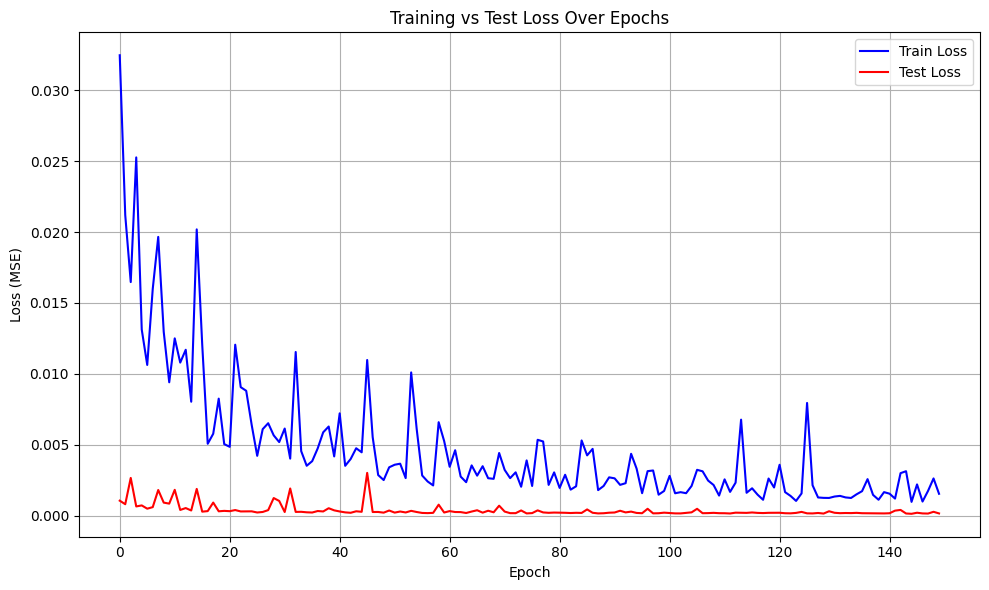

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# فرض: preds_conc و preds_flow خروجی مدل (torch tensors) هستند، بعد از مدل.eval() و بدون grad

# 1. انتقال به CPU و تبدیل به numpy
preds_conc_np = preds_conc.cpu().numpy()
preds_flow_np = preds_flow.cpu().numpy()

# 2. برگرداندن مقیاس با استفاده از scalerهای قبلی
preds_conc_original = y_scaler_conc.inverse_transform(preds_conc_np)
preds_flow_original = y_scaler_flow.inverse_transform(preds_flow_np)

# حالا preds_conc_original و preds_flow_original، پیش‌بینی‌ها به مقیاس اصلی هستند.

In [37]:
import pandas as pd

# اول، خروجی‌های واقعی تست (y_test) رو به مقیاس اصلی برگردونیم
# فرضا y_test_conc_scaled و y_test_flow_scaled داریم، پس:
y_test_conc_original = y_scaler_conc.inverse_transform(y_test_conc_scaled)
y_test_flow_original = y_scaler_flow.inverse_transform(y_test_flow_scaled)

# چون توی تست به صورت دنباله‌ای استفاده می‌کنی (با seq_len)، باید یادت باشه همون offset رو اعمال کنی:
y_true_conc = y_test_conc_original[seq_len - 1:, :]
y_true_flow = y_test_flow_original[seq_len - 1:, :]

# حالا با پیش‌بینی‌ها
y_pred_conc = preds_conc_original
y_pred_flow = preds_flow_original

# ادغام هر دو بخش (غلظت + دبی) در قالب numpy
y_true_inv = np.hstack([y_true_conc, y_true_flow])
y_pred_inv = np.hstack([y_pred_conc, y_pred_flow])

# نام دقیق ستون‌ها (5 خروجی)
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # اسامی دلخواهت اینجا بذار

# ساخت دیکشنری برای DataFrame
data = {}
for i, label in enumerate(labels):
    data[f'Actual {label}'] = y_true_inv[:, i]
    data[f'Predicted {label}'] = y_pred_inv[:, i]

# ساخت DataFrame
results = pd.DataFrame(data)

print(results.head())

   Actual Target1  Predicted Target1  Actual Target2  Predicted Target2  \
0        0.933322           0.933317        0.999927           0.999927   
1        0.933682           0.933683        0.999927           0.999927   
2        0.933674           0.933681        0.999927           0.999927   
3        0.933701           0.933710        0.999927           0.999927   
4        0.932619           0.932617        0.999927           0.999927   

   Actual Target3  Predicted Target3  Actual Target4  Predicted Target4  \
0        0.740144           0.740136         48.8496          48.845936   
1        0.739934           0.739982         48.9809          48.981709   
2        0.741223           0.741256         48.3745          48.371880   
3        0.739834           0.739831         49.0406          49.042130   
4        0.739419           0.739414         48.8829          48.886257   

   Actual Target5  Predicted Target5  
0         286.417         286.393494  
1         287.185   

In [38]:
import numpy as np

def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    total = y_true.shape[0] if y_true.ndim == 1 else y_true.shape[0] * y_true.shape[1]
    return (within_tol / total) * 100

In [39]:
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # به ترتیب: 3 تا غلظت، 2 تا دبی

# تولرانس‌های جداگانه برای هر خروجی
tolerances_per_output = {
    'Target1': [0.001, 0.0001, 0.00005],  # غلظت
    'Target2': [0.001, 0.0001, 0.00005],  # غلظت
    'Target3': [0.001, 0.0001, 0.00005],  # غلظت
    'Target4': [0.02, 0.05, 0.1],             # دبی
    'Target5': [0.02, 0.05, 0.1]              # دبی
}
all_results = {label: [] for label in labels}

In [40]:
# بررسی دقت بر اساس تولرانس‌های اختصاصی هر خروجی
for label_index, label in enumerate(labels):
    print(f"\n--- Accuracy for {label} ---")
    for tol in tolerances_per_output[label]:
        acc = percentage_within_tolerance(y_true_inv[:, label_index], y_pred_inv[:, label_index], tolerance=tol)
        all_results[label].append(acc)
        print(f"Tolerance ±{tol}: {acc:.2f}%")


--- Accuracy for Target1 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 99.95%
Tolerance ±5e-05: 99.23%

--- Accuracy for Target2 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 100.00%

--- Accuracy for Target3 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 98.06%

--- Accuracy for Target4 ---
Tolerance ±0.02: 99.59%
Tolerance ±0.05: 100.00%
Tolerance ±0.1: 100.00%

--- Accuracy for Target5 ---
Tolerance ±0.02: 74.13%
Tolerance ±0.05: 97.93%
Tolerance ±0.1: 99.73%


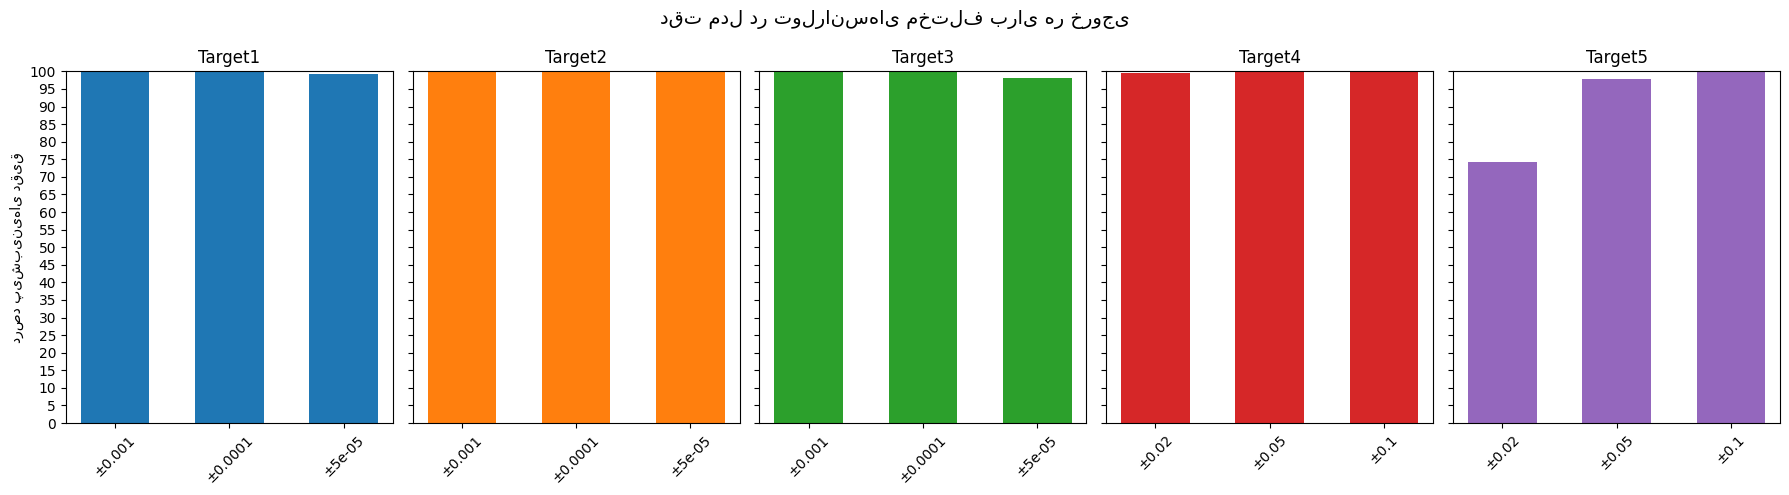

In [41]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# فرض: all_results دیکشنری با مقادیر لیستی از دقت‌ها
# مثل {'Target1': [...], 'Target2': [...], ...}

fig, axs = plt.subplots(1, len(labels), figsize=(18, 5), sharey=True)

for i, label in enumerate(labels):
    accs = all_results[label]
    tols = tolerances_per_output[label]
    
    x = np.arange(len(tols))
    axs[i].bar(x, accs, color=plt.cm.tab10(i), width=0.6)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels([f'±{t}' for t in tols], rotation=45)
    axs[i].set_title(label)
    axs[i].set_ylim(0, 100)
    axs[i].set_yticks(np.arange(0, 101, 5))

axs[0].set_ylabel("درصد پیش‌بینی‌های دقیق")
fig.suptitle("دقت مدل در تولرانس‌های مختلف برای هر خروجی", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true_inv, y_pred_inv)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

In [43]:
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 8.777897544564152e-05
MAE: 0.0035777023348864435
R2 Score: 0.9924869163569146


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # اسم دقیق متغیرها

for i, label in enumerate(labels):
    mse_i = mean_squared_error(y_true_inv[:, i], y_pred_inv[:, i])
    mae_i = mean_absolute_error(y_true_inv[:, i], y_pred_inv[:, i])
    r2_i = r2_score(y_true_inv[:, i], y_pred_inv[:, i])
    print(f"{label} --> MSE: {mse_i:.4f} | MAE: {mae_i:.4f} | R²: {r2_i:.4f}")

Target1 --> MSE: 0.0000 | MAE: 0.0000 | R²: 0.9997
Target2 --> MSE: 0.0000 | MAE: 0.0000 | R²: 0.9635
Target3 --> MSE: 0.0000 | MAE: 0.0000 | R²: 0.9994
Target4 --> MSE: 0.0000 | MAE: 0.0029 | R²: 0.9998
Target5 --> MSE: 0.0004 | MAE: 0.0149 | R²: 0.9999


Plotting first 100 samples.


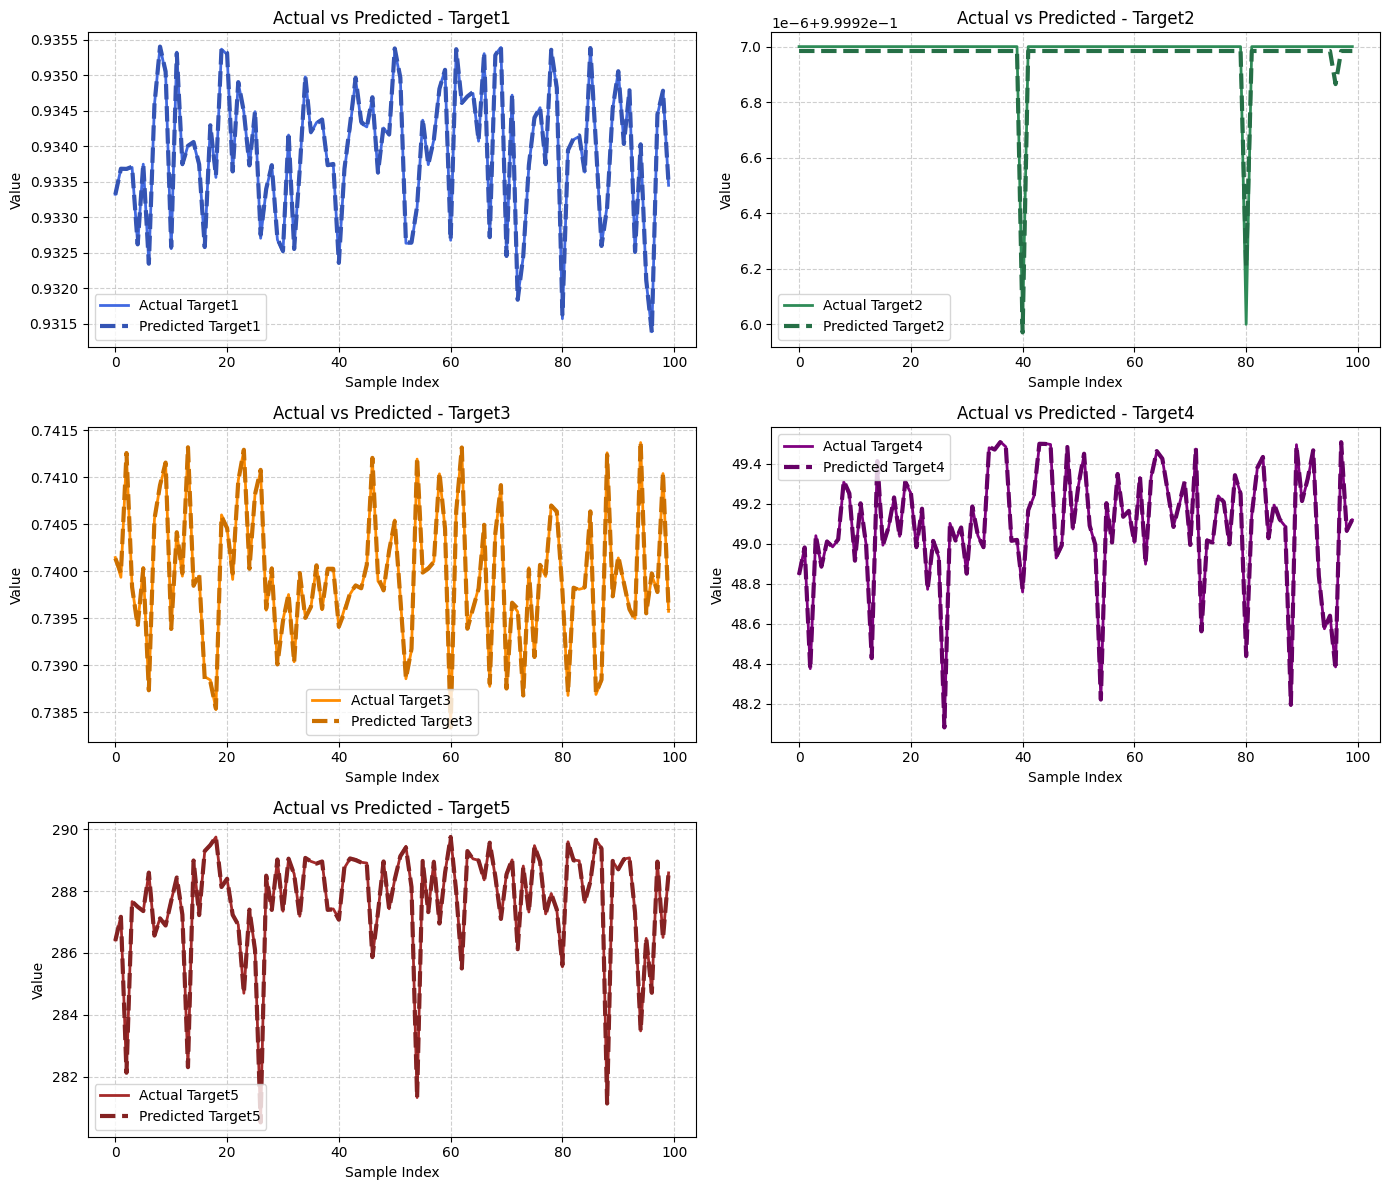

In [45]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# رنگ‌های پایه برای هر Target
base_colors = ['royalblue', 'seagreen', 'darkorange', 'purple', 'brown']

# انتخاب زیرمجموعه داده‌ها برای رسم
num_samples = len(results)
max_samples = 100
if num_samples > max_samples:
    subset = results.iloc[:max_samples]
    print(f"Plotting first {max_samples} samples.")
else:
    subset = results
    print("Plotting all available samples.")

plt.figure(figsize=(14, 12))

for i, label in enumerate(labels):
    plt.subplot(3, 2, i + 1)
    
    actual_color = base_colors[i]
    
    # برای رنگ پردیکت، یک رنگ روشن‌تر یا تیره‌تر بساز (مثلا با تغییر روشنایی)
    predicted_color = mcolors.to_rgba(actual_color)
    # می‌تونیم رنگ رو روشن‌تر کنیم:
    predicted_color = (predicted_color[0]*0.8, predicted_color[1]*0.8, predicted_color[2]*0.8, 1)  # کمی تیره‌تر و پررنگ
    
    # رسم Actual: رنگ اصلی، ضخامت نرمال، خط پیوسته
    plt.plot(subset[f'Actual {label}'], label=f'Actual {label}', color=actual_color, linewidth=2)
    
    # رسم Predicted: رنگ تیره‌تر، ضخامت بیشتر، خط‌چین
    plt.plot(subset[f'Predicted {label}'], label=f'Predicted {label}', color=predicted_color, linestyle='--', linewidth=3)
    
    plt.title(f'Actual vs Predicted - {label}')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [46]:
model.eval()
with torch.no_grad():
    xb, yb_conc, yb_flow = next(iter(train_loader))
    xb = xb.to(device)
    out_conc, out_flow, alpha = model(xb)
    print("Alpha attention shape:", alpha.shape)
    print("Alpha attention example (batch=0):", alpha[0].cpu().numpy())

Alpha attention shape: torch.Size([64, 83])
Alpha attention example (batch=0): [5.74691461e-10 3.90068755e-10 1.32667891e-10 8.98800408e-06
 9.30115873e-10 1.79630537e-02 1.28795516e-10 3.44567513e-10
 8.38640204e-04 5.88476780e-07 2.22412241e-10 1.84473103e-10
 1.27281158e-10 2.85415980e-03 2.38781939e-10 9.96233673e-09
 2.95441598e-03 5.78627979e-10 1.08493318e-10 2.05839387e-10
 2.19920580e-03 1.88933508e-10 1.45354936e-10 3.48850004e-10
 1.21974167e-10 4.69779216e-10 3.67670672e-10 5.24929237e-05
 1.23887178e-10 1.91387503e-10 3.26414229e-10 1.66893901e-10
 2.37519171e-10 2.85865248e-10 1.62760824e-01 1.80911286e-10
 3.74030945e-10 1.32465379e-06 5.90469340e-10 3.22843671e-01
 7.84379728e-10 9.83823245e-10 2.23061637e-04 3.99882238e-10
 1.08821929e-01 1.44014856e-10 2.60663510e-05 4.92782518e-03
 3.01522973e-10 1.00498199e-01 3.59981378e-10 3.53267969e-04
 1.58418778e-10 2.19959884e-10 3.55529689e-10 1.30283881e-10
 2.63139038e-10 6.80164203e-10 1.18750246e-10 1.07875034e-01
 1.603

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


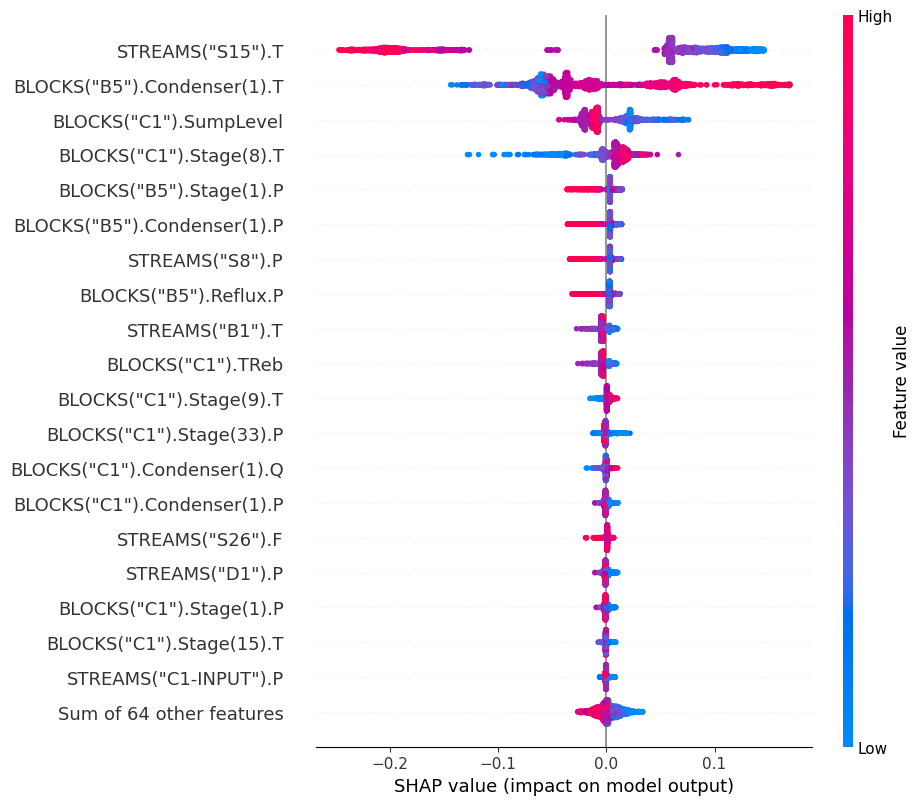

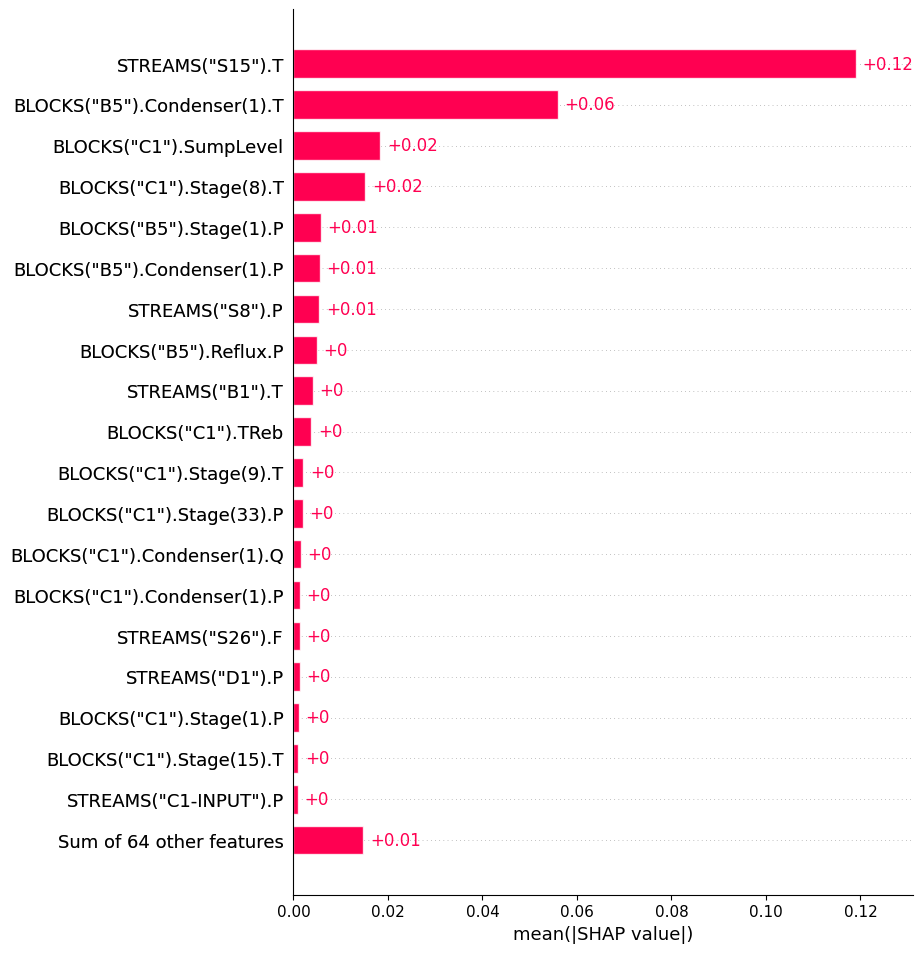

In [48]:
import shap
from sklearn.ensemble import RandomForestRegressor

# گرفتن نام ویژگی‌ها از DataFrame
feature_names = df.columns[:-5]  # چون 5 ستون آخر خروجی هستن

# انتخاب یک خروجی برای نمونه (مثلاً Target1 = غلظت اول)
target_index = 0  # اگر بخوای Target1 رو تحلیل کنی

# مدل ساده‌ی RandomForest فقط برای نمایش SHAP
model_rf = RandomForestRegressor(n_estimators=500,random_state=42)
model_rf.fit(x_train_scaled, y_train_conc_scaled[:, target_index])  # فقط Target1

# تبدیل X تست به DataFrame با نام ستون‌ها
x_test_df = pd.DataFrame(x_test_scaled, columns=feature_names)

# اعمال SHAP با استفاده از DataFrame (تا اسم ویژگی‌ها حفظ بشه)
explainer = shap.Explainer(model_rf)
shap_values = explainer(x_test_df)

# نمایش گرافیکی SHAP برای ویژگی‌ها (با اسم‌ها)
shap.plots.beeswarm(shap_values, max_display=20)
shap.plots.bar(shap_values, max_display=20)